# Notebook 4 ? Training-Set Exploratory Data Analysis

## Purpose

Perform detailed exploratory data analysis using **only the training split** created in Notebook 3.

The validation and test sets remain untouched to prevent information leakage.

## Input

`data/processed/train.parquet`

## Target

`is_late`

- `0` = delivered on time
- `1` = delivered late

## Main goals

- validate the training artifact;
- inspect schema and data types;
- analyze missing values;
- inspect class imbalance;
- understand numerical and categorical variables;
- identify suspicious or unusable features;
- audit target leakage;
- prepare feature decisions for modelling.


## 1. Imports and project paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print("Imports completed successfully.")

NumPy version: 2.5.2
pandas version: 3.0.5
Imports completed successfully.


In [2]:
WORKING_DIR = Path.cwd().resolve()
PROJECT_ROOT = WORKING_DIR.parent if WORKING_DIR.name == "notebooks" else WORKING_DIR

assert (PROJECT_ROOT / "docker-compose.yml").exists(), (
    "Project root could not be identified."
)

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "train.parquet"

assert TRAIN_PATH.exists(), (
    f"Training artifact not found: {TRAIN_PATH}. Run Notebook 3 first."
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Training artifact: {TRAIN_PATH}")

Project root: D:\Documents\mlops-olist
Training artifact: D:\Documents\mlops-olist\data\processed\train.parquet


## 2. Load and validate the training split

Only `train.parquet` is loaded in this notebook. Validation and test data remain closed.


In [3]:
train = pd.read_parquet(TRAIN_PATH)

print(f"Training shape: {train.shape}")
print(f"Unique order IDs: {train['order_id'].nunique()}")
print(f"Duplicated order IDs: {train['order_id'].duplicated().sum()}")
print(f"Missing target values: {train['is_late'].isna().sum()}")
print(f"Late orders: {int(train['is_late'].sum()):,}")
print(f"Late-delivery rate: {train['is_late'].mean():.4%}")

assert train.shape == (67_529, 67)
assert train["order_id"].is_unique
assert train["is_late"].notna().all()
assert set(train["is_late"].unique()) == {0, 1}

display(train.head())

Training shape: (67529, 67)
Unique order IDs: 67529
Duplicated order IDs: 0
Missing target values: 0
Late orders: 5,290
Late-delivery rate: 7.8337%


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_record_found,customer_unique_id,...,post_delivery_review_creation_date_min,post_delivery_review_answer_timestamp_max,customer_lat_median,customer_lng_median,customer_geolocation_record_count,primary_seller_lat_median,primary_seller_lng_median,primary_seller_geolocation_record_count,delivery_delay_days,is_late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,True,830d5b7aaa3b6f1e9ad63703bec97d23,...,2016-10-06,2016-10-07 18:32:28,-20.585396,-47.863156,345.0,-25.507138,-49.276529,141.0,36,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,True,32ea3bdedab835c3aa6cb68ce66565ef,...,2016-10-26,2016-10-30 21:32:15,-23.581321,-46.635726,45.0,-24.958205,-53.461305,133.0,-1,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,True,2f64e403852e6893ae37485d5fcacdaf,...,2016-10-28,2016-10-29 11:29:53,-28.291275,-53.501401,269.0,-21.142974,-48.994517,53.0,-11,0
3,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,True,61db744d2f835035a5625b59350c6b63,...,2016-11-04,2016-11-04 23:45:17,-30.040958,-51.212970,234.0,-23.503591,-47.429639,103.0,-26,0
4,d207cc272675637bfed0062edffd0818,b8cf418e97ae795672d326288dfab7a7,delivered,2016-10-03 22:06:03,2016-10-04 10:28:07,2016-10-21 14:23:37,2016-10-31 11:07:42,2016-11-23,True,8d3a54507421dbd2ce0a1d58046826e0,...,2016-11-01,2016-11-02 16:52:00,-22.894390,-47.173213,280.0,-21.757690,-48.829768,286.0,-23,0


## 3. Schema and data types

In [4]:
schema_summary = pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.astype(str).values,
    "non_null": train.notna().sum().values,
    "missing": train.isna().sum().values,
    "unique": train.nunique(dropna=True).values,
})

schema_summary["missing_percent"] = (
    schema_summary["missing"] / len(train) * 100
).round(4)

display(schema_summary)

print("\nData type counts:")
display(schema_summary["dtype"].value_counts().rename("column_count"))

,column,dtype,non_null,missing,unique,missing_percent
0,order_id,str,67529,0,67529,0.0000
1,customer_id,str,67529,0,67529,0.0000
2,order_status,str,67529,0,1,0.0000
3,order_purchase_timestamp,datetime64[us],67529,0,67151,0.0000
4,order_approved_at,datetime64[us],67515,14,63147,0.0207
...,...,...,...,...,...,...
62,primary_seller_lat_median,float64,67364,165,1673,0.2443
63,primary_seller_lng_median,float64,67364,165,1673,0.2443
64,primary_seller_geolocation_record_count,float64,67364,165,382,0.2443
65,delivery_delay_days,int16,67529,0,196,0.0000



Data type counts:


dtype
float64           42
str               13
datetime64[us]     9
bool               1
int16              1
int8               1
Name: column_count, dtype: int64

## 4. Missing-value analysis

Missing values are inspected before deciding how preprocessing should handle them.


In [5]:
missing_summary = (
    train.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(train) * 100
).round(4)

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values(["missing_percent", "missing_count"], ascending=False)
)

print(f"Columns with missing values: {len(missing_summary)}")
display(missing_summary)

Columns with missing values: 34


,missing_count,missing_percent
post_delivery_review_message_length_mean,39746,58.8577
product_name_length_mean,1197,1.7726
product_description_length_mean,1197,1.7726
product_photos_qty_mean,1197,1.7726
post_delivery_review_count,515,0.7626
post_delivery_review_score_mean,515,0.7626
post_delivery_review_score_min,515,0.7626
post_delivery_review_score_max,515,0.7626
post_delivery_review_title_count,515,0.7626
post_delivery_review_message_count,515,0.7626


## 5. Target distribution

Late delivery is the positive class. Understanding its prevalence is important because accuracy alone can be misleading for an imbalanced classification problem.


,is_late,count,percent
0,0,62239,92.1663
1,1,5290,7.8337


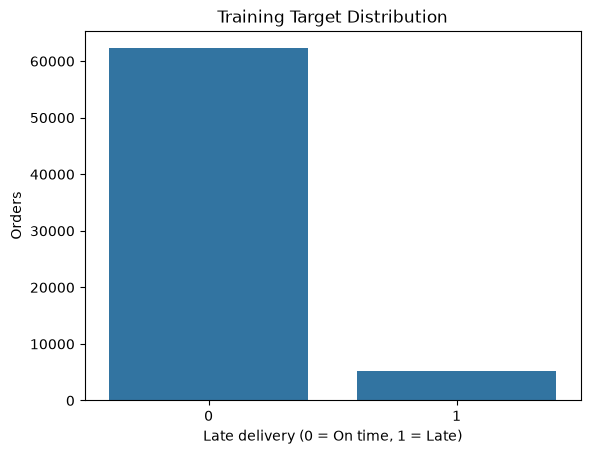

Late-delivery rate: 7.8337%


In [6]:
target_summary = (
    train["is_late"]
    .value_counts()
    .sort_index()
    .rename_axis("is_late")
    .reset_index(name="count")
)

target_summary["percent"] = (
    target_summary["count"] / len(train) * 100
).round(4)

display(target_summary)

ax = sns.countplot(data=train, x="is_late")
ax.set_title("Training Target Distribution")
ax.set_xlabel("Late delivery (0 = On time, 1 = Late)")
ax.set_ylabel("Orders")
plt.show()

print(f"Late-delivery rate: {train['is_late'].mean():.4%}")

## 6. Numerical and categorical feature inventory

In [7]:
numeric_columns = train.select_dtypes(include="number").columns.tolist()
datetime_columns = train.select_dtypes(
    include=["datetime", "datetimetz"]
).columns.tolist()
categorical_columns = [
    c for c in train.columns
    if c not in numeric_columns and c not in datetime_columns
]

print(f"Total columns: {train.shape[1]}")
print(f"Numeric columns: {len(numeric_columns)}")
print(f"Datetime columns: {len(datetime_columns)}")
print(f"Other/categorical columns: {len(categorical_columns)}")

print("\nNumeric columns:")
print(numeric_columns)

print("\nDatetime columns:")
print(datetime_columns)

print("\nOther/categorical columns:")
print(categorical_columns)

Total columns: 67
Numeric columns: 44
Datetime columns: 9
Other/categorical columns: 14

Numeric columns:
['item_count', 'unique_product_count', 'unique_seller_count', 'item_price_total', 'item_price_mean', 'item_price_max', 'freight_value_total', 'freight_value_mean', 'unique_product_category_count', 'product_name_length_mean', 'product_description_length_mean', 'product_photos_qty_mean', 'product_weight_g_total', 'product_weight_g_mean', 'product_length_cm_mean', 'product_height_cm_mean', 'product_width_cm_mean', 'primary_category_item_count', 'unique_seller_city_count', 'unique_seller_state_count', 'primary_seller_item_count', 'payment_record_count', 'unique_payment_type_count', 'payment_value_total', 'payment_value_mean', 'payment_installments_max', 'payment_installments_mean', 'primary_payment_type_value', 'primary_payment_type_record_count', 'post_delivery_review_count', 'post_delivery_review_score_mean', 'post_delivery_review_score_min', 'post_delivery_review_score_max', 'post_d

## 7. Numerical summary

In [8]:
numeric_summary_columns = [
    c for c in numeric_columns
    if c != "is_late"
]

numeric_summary = train[numeric_summary_columns].describe().T

numeric_summary["missing"] = train[numeric_summary_columns].isna().sum()
numeric_summary["unique"] = train[numeric_summary_columns].nunique()

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,missing,unique
item_count,67529.0,1.142072,0.541640,1.000000,1.000000,1.000000,1.000000,21.000000,0,17
unique_product_count,67529.0,1.037702,0.222199,1.000000,1.000000,1.000000,1.000000,7.000000,0,7
unique_seller_count,67529.0,1.012054,0.114815,1.000000,1.000000,1.000000,1.000000,5.000000,0,5
item_price_total,67529.0,135.888797,205.194019,2.290000,45.900000,85.000000,149.900000,13440.000000,0,5799
item_price_mean,67529.0,124.239070,185.659661,1.514286,41.000000,78.970000,139.900000,6735.000000,0,5238
item_price_max,67529.0,124.847354,186.037538,2.290000,41.900000,79.000000,139.900000,6735.000000,0,4491
freight_value_total,67529.0,22.245936,20.002594,0.000000,14.100000,16.790000,23.700000,1002.290000,0,6139
freight_value_mean,67529.0,19.640187,14.382949,0.000000,13.440000,16.110000,20.290000,338.300000,0,5770
unique_product_category_count,67529.0,1.007375,0.086762,1.000000,1.000000,1.000000,1.000000,3.000000,0,3
product_name_length_mean,66332.0,48.738921,9.987491,5.000000,42.000000,52.000000,57.000000,72.000000,1197,232


## 8. Leakage audit

Some columns exist in the labelled dataset for auditing, but they cannot be model predictors because they reveal the outcome or become available only after delivery.

Using them would allow the model to learn information that would not exist at prediction time.


In [9]:
known_non_feature_columns = [
    "is_late",
    "delivery_delay_days",
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
    "post_delivery_review_count",
    "post_delivery_review_score_mean",
    "post_delivery_review_score_min",
    "post_delivery_review_score_max",
    "post_delivery_review_title_count",
    "post_delivery_review_message_count",
    "post_delivery_review_message_length_mean",
    "post_delivery_review_creation_date_min",
    "post_delivery_review_answer_timestamp_max",
]

present_non_features = [
    c for c in known_non_feature_columns
    if c in train.columns
]

print("Known target/outcome/post-delivery columns:")
for column in present_non_features:
    print(f"- {column}")

print(
    "\nThese columns may be inspected for audit purposes, "
    "but they are NOT approved model features."
)

Known target/outcome/post-delivery columns:
- is_late
- delivery_delay_days
- order_delivered_customer_date
- order_delivered_carrier_date
- post_delivery_review_count
- post_delivery_review_score_mean
- post_delivery_review_score_min
- post_delivery_review_score_max
- post_delivery_review_title_count
- post_delivery_review_message_count
- post_delivery_review_message_length_mean
- post_delivery_review_creation_date_min
- post_delivery_review_answer_timestamp_max

These columns may be inspected for audit purposes, but they are NOT approved model features.


## 9. Purchase-time behaviour

Because the train/validation/test split is chronological, we inspect temporal behaviour inside the training period only.


,purchase_month,order_count,late_count,late_rate,late_rate_percent
0,2016-09,1,1,1.000000,100.0000
1,2016-10,265,2,0.007547,0.7547
2,2016-12,1,0,0.000000,0.0000
3,2017-01,750,22,0.029333,2.9333
4,2017-02,1653,49,0.029643,2.9643
5,2017-03,2546,116,0.045562,4.5562
6,2017-04,2303,151,0.065567,6.5567
7,2017-05,3545,106,0.029901,2.9901
8,2017-06,3135,95,0.030303,3.0303
9,2017-07,3872,108,0.027893,2.7893


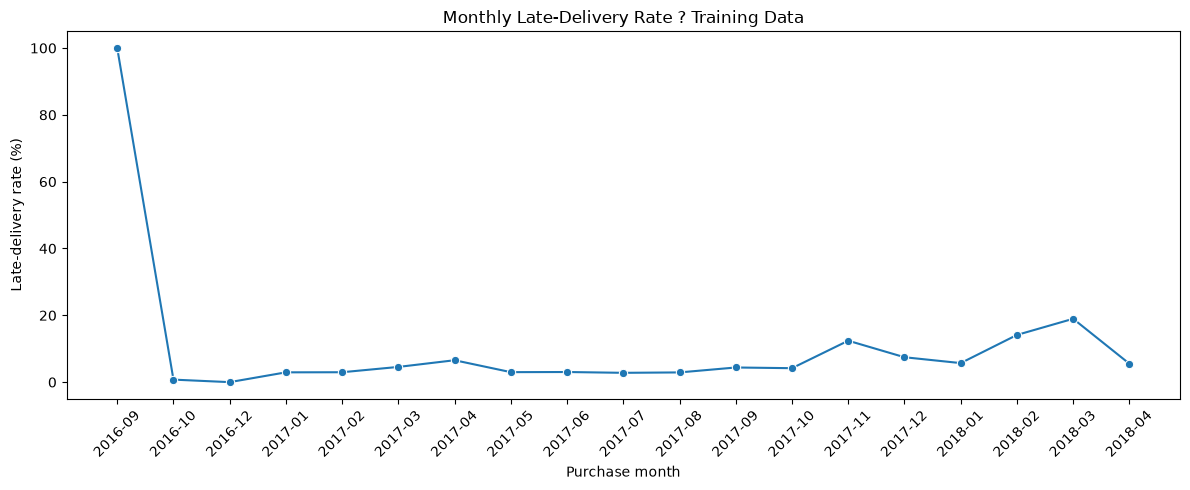

In [10]:
train["order_purchase_timestamp"] = pd.to_datetime(
    train["order_purchase_timestamp"]
)

monthly_train = (
    train.assign(
        purchase_month=train["order_purchase_timestamp"].dt.to_period("M").astype(str)
    )
    .groupby("purchase_month")
    .agg(
        order_count=("order_id", "count"),
        late_count=("is_late", "sum"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

monthly_train["late_rate_percent"] = (
    monthly_train["late_rate"] * 100
).round(4)

display(monthly_train)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_train,
    x="purchase_month",
    y="late_rate_percent",
    marker="o",
)
plt.xticks(rotation=45)
plt.title("Monthly Late-Delivery Rate ? Training Data")
plt.xlabel("Purchase month")
plt.ylabel("Late-delivery rate (%)")
plt.tight_layout()
plt.show()

## 10. Training EDA checkpoint

At this stage we have:

- validated the training artifact;
- confirmed that only the training split was opened;
- inspected the schema;
- identified missing values;
- measured target imbalance;
- grouped columns by data type;
- summarized numerical variables;
- identified known target-leakage fields;
- inspected temporal late-delivery behaviour.

The next EDA stage will examine candidate predictors and their relationships with late delivery before final feature selection and preprocessing.


In [11]:
print("NOTEBOOK 4 ? EDA CHECKPOINT")
print(f"Rows: {len(train):,}")
print(f"Columns: {train.shape[1]}")
print(f"Late-delivery rate: {train['is_late'].mean():.4%}")
print(f"Columns with missing values: {len(missing_summary)}")
print(f"Known non-feature/leakage columns: {len(present_non_features)}")
print("Validation data opened: NO")
print("Test data opened: NO")
print("EDA checkpoint complete: YES")

NOTEBOOK 4 ? EDA CHECKPOINT
Rows: 67,529
Columns: 67
Late-delivery rate: 7.8337%
Columns with missing values: 34
Known non-feature/leakage columns: 13
Validation data opened: NO
Test data opened: NO
EDA checkpoint complete: YES


## 11. Candidate predictor inventory

We now examine variables that may be useful for prediction while continuing to exclude known target, outcome, post-delivery, and identifier fields.

This is still feature investigation ? not final model feature approval.


In [12]:
identifier_columns = [
    c for c in train.columns
    if c == "order_id"
    or c.endswith("_id")
]

excluded_columns = set(present_non_features) | set(identifier_columns)

candidate_numeric_columns = [
    c for c in numeric_columns
    if c not in excluded_columns
]

candidate_categorical_columns = [
    c for c in categorical_columns
    if c not in excluded_columns
]

print(f"Identifier-like columns excluded: {len(identifier_columns)}")
print(f"Candidate numeric columns: {len(candidate_numeric_columns)}")
print(f"Candidate categorical columns: {len(candidate_categorical_columns)}")

print("\nIdentifier-like columns:")
for column in identifier_columns:
    print(f"- {column}")

Identifier-like columns excluded: 4
Candidate numeric columns: 35
Candidate categorical columns: 10

Identifier-like columns:
- order_id
- customer_id
- customer_unique_id
- primary_seller_id


## 12. Numerical relationships with late delivery

For numerical candidate variables, Pearson correlation with the binary target is used as a simple screening measure.

This does **not** prove causation or automatically approve a feature. It only highlights variables worth examining further.


Numerical candidate relationships calculated: 35


,feature,correlation_with_is_late,absolute_correlation,non_null_rows,unique_values
0,customer_lng_median,0.084159,0.084159,67348,13626
1,freight_value_mean,0.072402,0.072402,67529,5770
2,customer_lat_median,0.061534,0.061534,67348,13627
3,freight_value_total,0.049650,0.049650,67529,6139
4,product_weight_g_mean,0.027706,0.027706,67513,2272
5,item_price_mean,0.027616,0.027616,67529,5238
6,item_price_max,0.026988,0.026988,67529,4491
7,payment_value_mean,0.025925,0.025925,67528,22036
8,primary_payment_type_value,0.025643,0.025643,67528,21215
9,payment_value_total,0.025551,0.025551,67528,21193


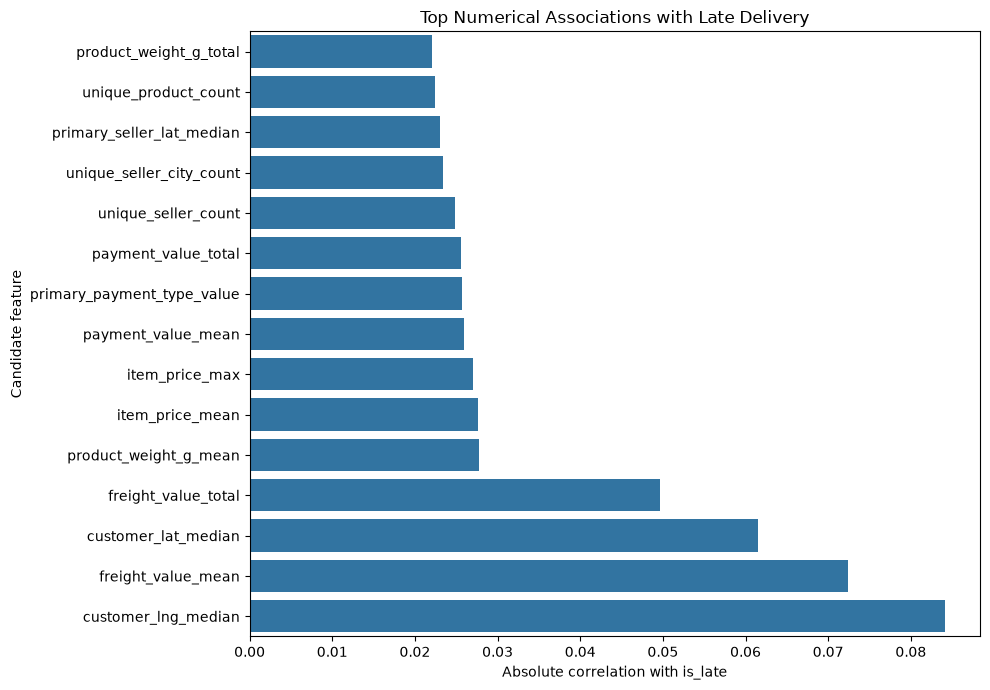

In [13]:
numeric_relationships = []

for column in candidate_numeric_columns:
    usable = train[[column, "is_late"]].dropna()

    if len(usable) == 0 or usable[column].nunique() <= 1:
        continue

    correlation = usable[column].corr(usable["is_late"])

    if pd.notna(correlation):
        numeric_relationships.append(
            {
                "feature": column,
                "correlation_with_is_late": correlation,
                "absolute_correlation": abs(correlation),
                "non_null_rows": len(usable),
                "unique_values": usable[column].nunique(),
            }
        )

numeric_relationship_summary = (
    pd.DataFrame(numeric_relationships)
    .sort_values("absolute_correlation", ascending=False)
    .reset_index(drop=True)
)

print(f"Numerical candidate relationships calculated: {len(numeric_relationship_summary)}")
display(numeric_relationship_summary.head(20))

if not numeric_relationship_summary.empty:
    plot_data = numeric_relationship_summary.head(15).sort_values(
        "absolute_correlation"
    )

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=plot_data,
        x="absolute_correlation",
        y="feature",
    )
    plt.title("Top Numerical Associations with Late Delivery")
    plt.xlabel("Absolute correlation with is_late")
    plt.ylabel("Candidate feature")
    plt.tight_layout()
    plt.show()

## 13. Categorical relationships with late delivery

Categorical variables are screened using the difference between the highest and lowest observed late-delivery rates.

Very rare categories are excluded from this screening to avoid drawing conclusions from tiny samples.


In [14]:
categorical_relationships = []

for column in candidate_categorical_columns:
    cardinality = train[column].nunique(dropna=True)

    if cardinality < 2 or cardinality > 50:
        continue

    grouped = (
        train.groupby(column, dropna=False)
        .agg(
            order_count=("order_id", "count"),
            late_rate=("is_late", "mean"),
        )
        .reset_index()
    )

    grouped = grouped[grouped["order_count"] >= 100]

    if len(grouped) < 2:
        continue

    rate_spread = grouped["late_rate"].max() - grouped["late_rate"].min()

    categorical_relationships.append(
        {
            "feature": column,
            "categories_total": cardinality,
            "categories_with_100_plus_orders": len(grouped),
            "late_rate_spread": rate_spread,
        }
    )

categorical_relationship_summary = (
    pd.DataFrame(categorical_relationships)
    .sort_values("late_rate_spread", ascending=False)
    .reset_index(drop=True)
    if categorical_relationships
    else pd.DataFrame()
)

print(
    f"Categorical candidate relationships calculated: "
    f"{len(categorical_relationship_summary)}"
)

if not categorical_relationship_summary.empty:
    display(categorical_relationship_summary.head(20))
else:
    print("No low-cardinality categorical candidates met the screening criteria.")

Categorical candidate relationships calculated: 3


,feature,categories_total,categories_with_100_plus_orders,late_rate_spread
0,customer_state,27,24,0.210484
1,primary_seller_state,22,12,0.050425
2,primary_payment_type,4,4,0.014240


## 14. Geographic patterns

State-level variables, when available, are inspected using training data only.

Geography can matter operationally because transportation distance, infrastructure, seller location, and customer location may influence delivery risk.


In [15]:
state_columns = [
    c for c in train.columns
    if c.lower().endswith("_state")
]

print(f"State columns found: {state_columns}")

for column in state_columns:
    state_summary = (
        train.groupby(column, dropna=False)
        .agg(
            orders=("order_id", "count"),
            late_orders=("is_late", "sum"),
            late_rate=("is_late", "mean"),
        )
        .reset_index()
    )

    state_summary = state_summary[state_summary["orders"] >= 100]
    state_summary["late_rate_percent"] = (
        state_summary["late_rate"] * 100
    ).round(4)

    state_summary = state_summary.sort_values(
        "late_rate",
        ascending=False,
    )

    print(f"\n=== {column} ===")
    display(state_summary.head(15))

State columns found: ['customer_state', 'primary_seller_state']

=== customer_state ===


,customer_state,orders,late_orders,late_rate,late_rate_percent
1,AL,298,74,0.248322,24.8322
9,MA,548,107,0.195255,19.5255
24,SE,246,42,0.170732,17.0732
5,CE,948,158,0.166667,16.6667
18,RJ,8965,1356,0.151255,15.1255
16,PI,348,49,0.140805,14.0805
4,BA,2307,301,0.130472,13.0472
14,PB,370,45,0.121622,12.1622
13,PA,718,87,0.121170,12.1170
7,ES,1445,172,0.119031,11.9031



=== primary_seller_state ===


,primary_seller_state,orders,late_orders,late_rate,late_rate_percent
15,RJ,2687,234,0.087086,8.7086
21,SP,47869,4075,0.085128,8.5128
4,ES,252,17,0.067460,6.7460
14,PR,5361,347,0.064727,6.4727
3,DF,585,35,0.059829,5.9829
1,BA,408,24,0.058824,5.8824
7,MG,5637,313,0.055526,5.5526
19,SC,2574,140,0.054390,5.4390
12,PE,210,11,0.052381,5.2381
5,GO,300,12,0.040000,4.0000


## 15. Missingness as a possible signal

Missing values can sometimes carry information.

For each candidate column with missing values, we compare the late-delivery rate when the value is missing versus present.

This does not mean missingness should automatically become a feature. It helps us decide how preprocessing should treat missing data.


In [16]:
missing_signal_records = []

for column in train.columns:
    if column in excluded_columns:
        continue

    missing_count = train[column].isna().sum()

    if missing_count == 0:
        continue

    missing_mask = train[column].isna()

    late_rate_missing = train.loc[missing_mask, "is_late"].mean()
    late_rate_present = train.loc[~missing_mask, "is_late"].mean()

    if pd.isna(late_rate_missing) or pd.isna(late_rate_present):
        continue

    missing_signal_records.append(
        {
            "feature": column,
            "missing_count": int(missing_count),
            "missing_percent": missing_count / len(train) * 100,
            "late_rate_when_missing": late_rate_missing,
            "late_rate_when_present": late_rate_present,
            "absolute_rate_difference": abs(
                late_rate_missing - late_rate_present
            ),
        }
    )

missing_signal_summary = (
    pd.DataFrame(missing_signal_records)
    .sort_values("absolute_rate_difference", ascending=False)
    .reset_index(drop=True)
    if missing_signal_records
    else pd.DataFrame()
)

print(f"Candidate columns with missingness signal checked: {len(missing_signal_summary)}")

if not missing_signal_summary.empty:
    display(missing_signal_summary.head(20))

Candidate columns with missingness signal checked: 24


,feature,missing_count,missing_percent,late_rate_when_missing,late_rate_when_present,absolute_rate_difference
0,primary_payment_type_value,1,0.001481,1.000000,0.078323,0.921677
1,primary_payment_type,1,0.001481,1.000000,0.078323,0.921677
2,payment_installments_max,1,0.001481,1.000000,0.078323,0.921677
3,payment_installments_mean,1,0.001481,1.000000,0.078323,0.921677
4,payment_value_mean,1,0.001481,1.000000,0.078323,0.921677
5,payment_value_total,1,0.001481,1.000000,0.078323,0.921677
6,unique_payment_type_count,1,0.001481,1.000000,0.078323,0.921677
7,payment_record_count,1,0.001481,1.000000,0.078323,0.921677
8,primary_payment_type_record_count,1,0.001481,1.000000,0.078323,0.921677
9,product_width_cm_mean,16,0.023694,0.000000,0.078355,0.078355


## 16. Purchase-time temporal patterns

The purchase timestamp is available at prediction time, so calendar features derived from it may be valid candidates.

We inspect day-of-week and hour-of-day patterns without using validation or test data.


Purchase day-of-week:


,purchase_day_of_week,orders,late_rate,late_rate_percent
0,Monday,10734,0.085895,8.5895
1,Tuesday,10729,0.079877,7.9877
2,Wednesday,10339,0.075249,7.5249
3,Thursday,10005,0.072464,7.2464
4,Friday,9884,0.081748,8.1748
5,Saturday,7593,0.078888,7.8888
6,Sunday,8245,0.072893,7.2893


Purchase hour:


,purchase_hour,orders,late_rate,late_rate_percent
0,0,1661,0.086695,8.6695
1,1,837,0.082437,8.2437
2,2,370,0.070270,7.0270
3,3,186,0.048387,4.8387
4,4,136,0.058824,5.8824
5,5,134,0.059701,5.9701
6,6,318,0.069182,6.9182
7,7,806,0.073201,7.3201
8,8,1951,0.074833,7.4833
9,9,3211,0.070694,7.0694


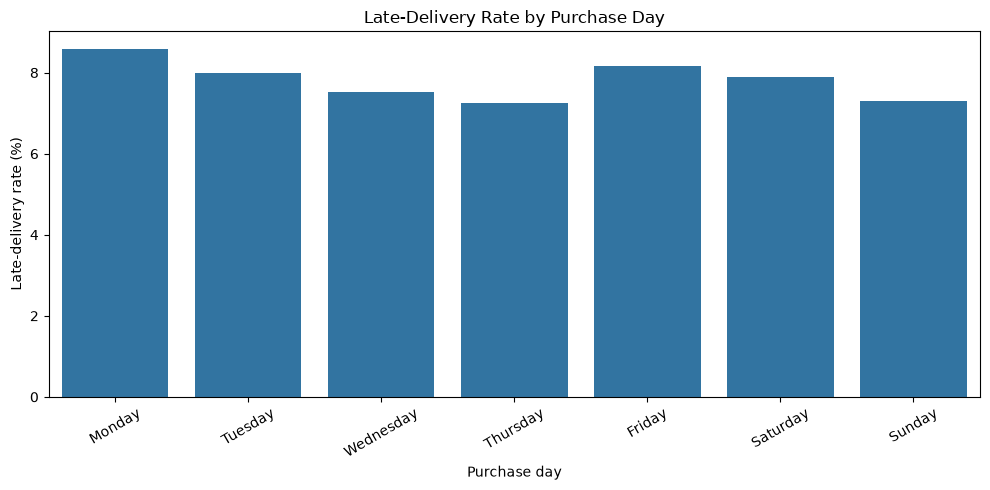

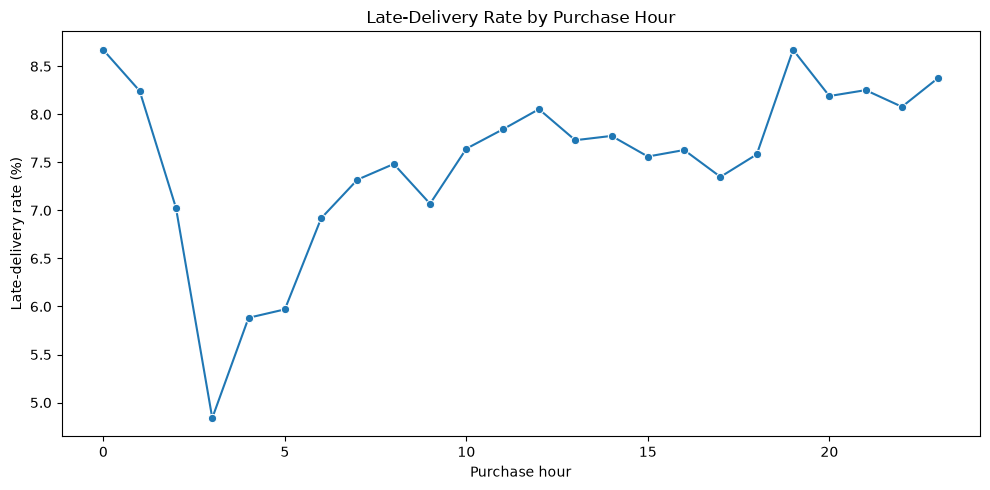

In [17]:
purchase_ts = pd.to_datetime(
    train["order_purchase_timestamp"],
    errors="coerce",
)

temporal_eda = train[["order_id", "is_late"]].copy()
temporal_eda["purchase_day_of_week"] = purchase_ts.dt.day_name()
temporal_eda["purchase_hour"] = purchase_ts.dt.hour

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

day_summary = (
    temporal_eda.groupby("purchase_day_of_week")
    .agg(
        orders=("order_id", "count"),
        late_rate=("is_late", "mean"),
    )
    .reindex(day_order)
    .reset_index()
)

day_summary["late_rate_percent"] = (
    day_summary["late_rate"] * 100
).round(4)

hour_summary = (
    temporal_eda.groupby("purchase_hour")
    .agg(
        orders=("order_id", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

hour_summary["late_rate_percent"] = (
    hour_summary["late_rate"] * 100
).round(4)

print("Purchase day-of-week:")
display(day_summary)

print("Purchase hour:")
display(hour_summary)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=day_summary,
    x="purchase_day_of_week",
    y="late_rate_percent",
)
plt.xticks(rotation=30)
plt.title("Late-Delivery Rate by Purchase Day")
plt.xlabel("Purchase day")
plt.ylabel("Late-delivery rate (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hour_summary,
    x="purchase_hour",
    y="late_rate_percent",
    marker="o",
)
plt.title("Late-Delivery Rate by Purchase Hour")
plt.xlabel("Purchase hour")
plt.ylabel("Late-delivery rate (%)")
plt.tight_layout()
plt.show()

## 17. Feature decision inventory

The goal here is not to finalize the modelling matrix yet.

Instead, every column receives an initial role:

- **TARGET** ? prediction target;
- **EXCLUDE_LEAKAGE** ? outcome/post-delivery information;
- **EXCLUDE_IDENTIFIER** ? identifiers that should not be learned as predictive signals;
- **DERIVE_AT_PREDICTION** ? timestamps that can be transformed into prediction-time features;
- **CANDIDATE_REVIEW** ? potentially usable but still requires preprocessing and availability review.


In [18]:
decision_records = []

for column in train.columns:
    if column == "is_late":
        role = "TARGET"
        reason = "Prediction target."

    elif column in present_non_features:
        role = "EXCLUDE_LEAKAGE"
        reason = "Target, delivery outcome, or post-delivery information."

    elif column in identifier_columns:
        role = "EXCLUDE_IDENTIFIER"
        reason = "Identifier rather than a generalizable predictive feature."

    elif column in {
        "order_purchase_timestamp",
        "order_estimated_delivery_date",
    }:
        role = "DERIVE_AT_PREDICTION"
        reason = "Timestamp is available before the delivery outcome; derive stable features."

    else:
        role = "CANDIDATE_REVIEW"
        reason = "Potential predictor; timing, missingness, and preprocessing still require review."

    decision_records.append(
        {
            "feature": column,
            "role": role,
            "reason": reason,
        }
    )

feature_decision_inventory = pd.DataFrame(decision_records)

print("Initial feature-role counts:")
display(
    feature_decision_inventory["role"]
    .value_counts()
    .rename("feature_count")
    .to_frame()
)

display(feature_decision_inventory)

Initial feature-role counts:


,feature_count
role,
CANDIDATE_REVIEW,48
EXCLUDE_LEAKAGE,12
EXCLUDE_IDENTIFIER,4
DERIVE_AT_PREDICTION,2
TARGET,1


,feature,role,reason
0,order_id,EXCLUDE_IDENTIFIER,Identifier rather than a generalizable predict...
1,customer_id,EXCLUDE_IDENTIFIER,Identifier rather than a generalizable predict...
2,order_status,CANDIDATE_REVIEW,"Potential predictor; timing, missingness, and ..."
3,order_purchase_timestamp,DERIVE_AT_PREDICTION,Timestamp is available before the delivery out...
4,order_approved_at,CANDIDATE_REVIEW,"Potential predictor; timing, missingness, and ..."
...,...,...,...
62,primary_seller_lat_median,CANDIDATE_REVIEW,"Potential predictor; timing, missingness, and ..."
63,primary_seller_lng_median,CANDIDATE_REVIEW,"Potential predictor; timing, missingness, and ..."
64,primary_seller_geolocation_record_count,CANDIDATE_REVIEW,"Potential predictor; timing, missingness, and ..."
65,delivery_delay_days,EXCLUDE_LEAKAGE,"Target, delivery outcome, or post-delivery inf..."


## 18. Numerical distributions and unusual values

Summary statistics alone can hide skewness and extreme observations.

Selected business-facing numeric variables are visualized using the
training split only. For visualization, the x-axis is limited to the
training 99th percentile when appropriate.

This clipping is **visual only**. No rows are removed and no values are
changed in the training data.


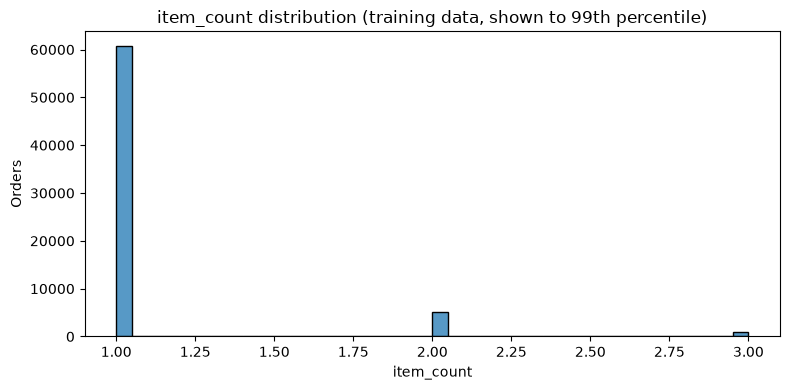

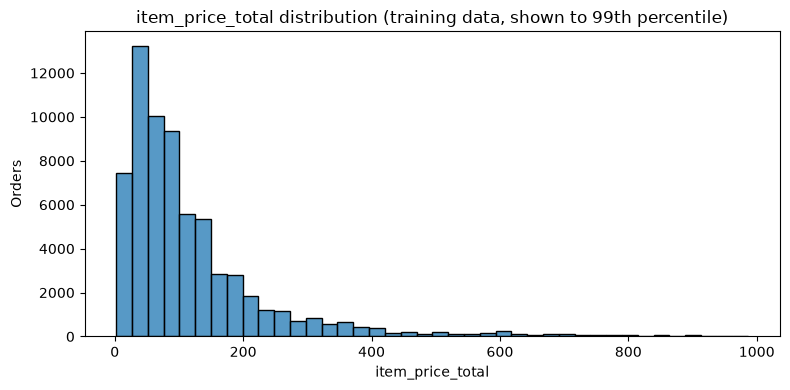

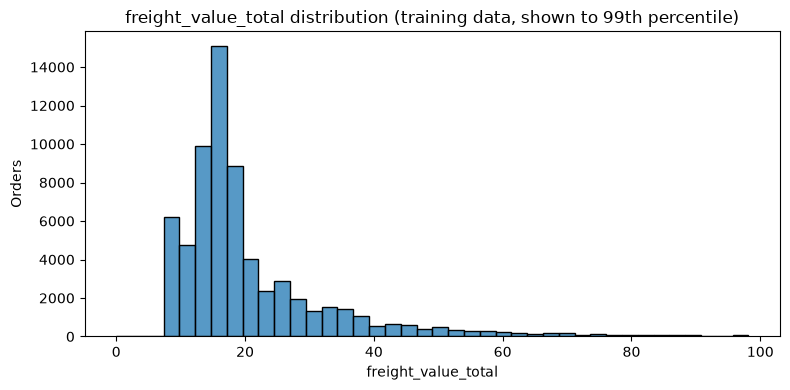

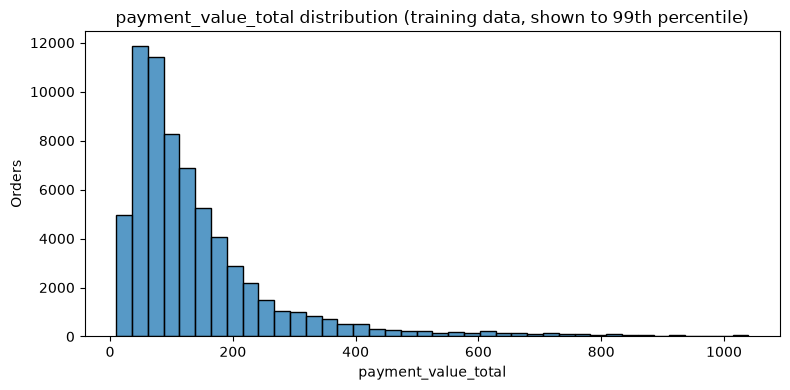

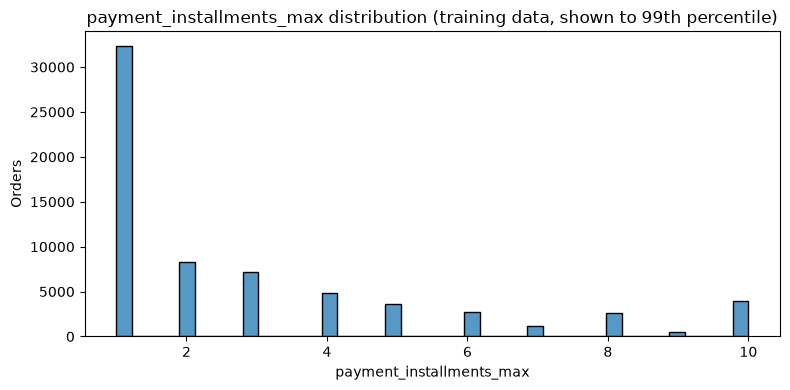

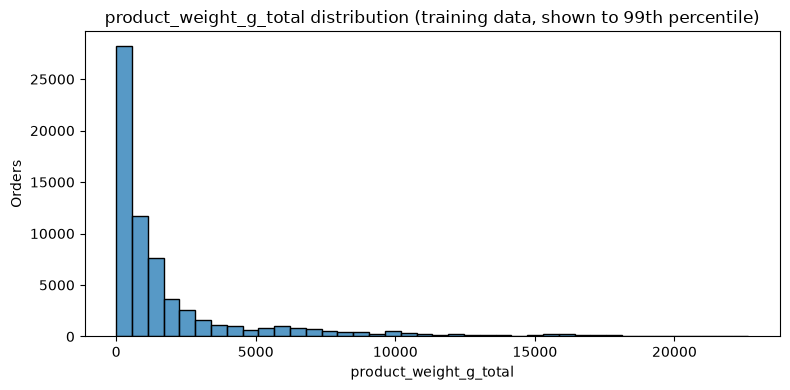

Numeric distributions inspected: 6
Rows removed for EDA distributions: 0


In [19]:
distribution_columns = [
    "item_count",
    "item_price_total",
    "freight_value_total",
    "payment_value_total",
    "payment_installments_max",
    "product_weight_g_total",
]

distribution_columns = [
    c for c in distribution_columns
    if c in train.columns
]

for column in distribution_columns:
    values = pd.to_numeric(
        train[column],
        errors="coerce",
    ).dropna()

    if values.empty:
        continue

    upper_visual_limit = values.quantile(0.99)

    plot_values = values[
        values <= upper_visual_limit
    ]

    plt.figure(figsize=(8, 4))

    sns.histplot(
        plot_values,
        bins=40,
        kde=False,
    )

    plt.title(
        f"{column} distribution "
        "(training data, shown to 99th percentile)"
    )

    plt.xlabel(column)
    plt.ylabel("Orders")
    plt.tight_layout()
    plt.show()

print(
    f"Numeric distributions inspected: "
    f"{len(distribution_columns)}"
)
print("Rows removed for EDA distributions: 0")

## 19. Explicit outlier audit

Potential outliers are identified with the IQR rule:

- lower bound = Q1 ? 1.5 ? IQR;
- upper bound = Q3 + 1.5 ? IQR.

The purpose is to understand the data?not to automatically delete
unusual observations.

Legitimate high-value orders can be operationally important, so any
future transformation must be fitted using training data rather than
silently removing observations during EDA.


In [20]:
outlier_records = []

for column in candidate_numeric_columns:
    values = pd.to_numeric(
        train[column],
        errors="coerce",
    ).dropna()

    if (
        len(values) == 0
        or values.nunique() <= 1
    ):
        continue

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    if pd.isna(iqr) or iqr == 0:
        continue

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (values < lower_bound)
        | (values > upper_bound)
    )

    outlier_count = int(
        outlier_mask.sum()
    )

    outlier_records.append(
        {
            "feature": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_percent": (
                outlier_count
                / len(values)
                * 100
            ),
        }
    )

outlier_summary = (
    pd.DataFrame(outlier_records)
    .sort_values(
        "outlier_percent",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    f"Numeric features audited for outliers: "
    f"{len(outlier_summary)}"
)

display(
    outlier_summary.head(20).style.format(
        {
            "q1": "{:.4f}",
            "q3": "{:.4f}",
            "iqr": "{:.4f}",
            "lower_bound": "{:.4f}",
            "upper_bound": "{:.4f}",
            "outlier_percent": "{:.4f}%",
        }
    )
)

print(
    "Automatic outlier deletion performed: NO"
)

Numeric features audited for outliers: 24


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
0,customer_lat_median,-23.5880,-19.9963,3.5917,-28.9756,-14.6088,11081,16.4533%
1,product_weight_g_mean,300.0000,1850.0000,1550.0000,-2025.0000,4175.0000,9769,14.4698%
2,product_weight_g_total,300.0000,2150.0000,1850.0000,-2475.0000,4925.0000,9509,14.0847%
3,freight_value_mean,13.4400,20.2900,6.8500,3.1650,30.5650,7104,10.5199%
4,freight_value_total,14.1000,23.7000,9.6000,-0.3000,38.1000,6630,9.8180%
5,primary_seller_lat_median,-23.6133,-21.7577,1.8556,-26.3966,-18.9743,5856,8.6931%
6,item_price_total,45.9000,149.9000,104.0000,-110.1000,305.9000,5362,7.9403%
7,payment_value_total,61.6300,175.5000,113.8700,-109.1750,346.3050,5309,7.8619%
8,primary_payment_type_value,61.0100,174.6800,113.6700,-109.4950,345.1850,5276,7.8131%
9,payment_value_mean,59.7600,173.4500,113.6900,-110.7750,343.9850,5236,7.7538%


Automatic outlier deletion performed: NO


## 20. Categorical cardinality and rare-category audit

Categorical variables require special care before one-hot encoding.

Two risks are examined:

1. **High cardinality** ? too many distinct values can create a very
   large sparse feature matrix and can behave like an identifier.
2. **Rare categories** ? categories with very few examples can lead
   to unstable estimates.

A category is considered rare here when it appears in fewer than
100 training orders. This threshold is for EDA diagnosis only; the
preprocessing rule will be fitted in Notebook 5.


In [21]:
categorical_profile_records = []

RARE_CATEGORY_EDA_THRESHOLD = 100
HIGH_CARDINALITY_THRESHOLD = 50

for column in candidate_categorical_columns:
    series = train[column]

    counts = series.value_counts(
        dropna=False,
    )

    non_missing_unique = int(
        series.nunique(dropna=True)
    )

    rare_mask = (
        counts
        < RARE_CATEGORY_EDA_THRESHOLD
    )

    rare_category_count = int(
        rare_mask.sum()
    )

    rare_row_count = int(
        counts[rare_mask].sum()
    )

    categorical_profile_records.append(
        {
            "feature": column,
            "unique_non_missing": (
                non_missing_unique
            ),
            "missing_count": int(
                series.isna().sum()
            ),
            "rare_category_count": (
                rare_category_count
            ),
            "rows_in_rare_categories": (
                rare_row_count
            ),
            "rare_row_percent": (
                rare_row_count
                / len(train)
                * 100
            ),
            "high_cardinality": (
                non_missing_unique
                > HIGH_CARDINALITY_THRESHOLD
            ),
        }
    )

categorical_profile = (
    pd.DataFrame(
        categorical_profile_records
    )
    .sort_values(
        [
            "high_cardinality",
            "unique_non_missing",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(categorical_profile)

high_cardinality_features = (
    categorical_profile.loc[
        categorical_profile[
            "high_cardinality"
        ],
        "feature",
    ]
    .tolist()
)

print(
    f"High-cardinality categorical features: "
    f"{len(high_cardinality_features)}"
)

for column in high_cardinality_features:
    print(f"- {column}")

,feature,unique_non_missing,missing_count,rare_category_count,rows_in_rare_categories,rare_row_percent,high_cardinality
0,customer_zip_code_prefix,13748,0,13747,67416,99.832664,True
1,customer_city,3747,0,3651,26651,39.466007,True
2,primary_seller_zip_code_prefix,1679,0,1533,25014,37.041863,True
3,primary_seller_city,489,0,389,7826,11.589095,True
4,primary_product_category,73,0,27,954,1.412726,True
5,customer_state,27,0,3,146,0.216203,False
6,primary_seller_state,22,0,10,259,0.383539,False
7,primary_payment_type,4,1,1,1,0.001481,False
8,order_status,1,0,0,0,0.000000,False
9,customer_record_found,1,0,0,0,0.000000,False


High-cardinality categorical features: 5
- customer_zip_code_prefix
- customer_city
- primary_seller_zip_code_prefix
- primary_seller_city
- primary_product_category


## 21. Categorical target crosstabs

Counts and late-delivery rates are inspected together.

This avoids a common mistake: treating an unusually high late rate
from a category with only a handful of observations as strong
evidence.

Only training data is used.


In [22]:
crosstab_columns = [
    "customer_state",
    "primary_seller_state",
    "primary_payment_type",
    "primary_product_category",
]

crosstab_columns = [
    c for c in crosstab_columns
    if c in train.columns
]

for column in crosstab_columns:
    grouped = (
        train.groupby(
            column,
            dropna=False,
        )
        .agg(
            total_orders=(
                "order_id",
                "count",
            ),
            late_orders=(
                "is_late",
                "sum",
            ),
            late_rate=(
                "is_late",
                "mean",
            ),
        )
        .reset_index()
    )

    grouped[
        "late_rate_percent"
    ] = (
        grouped["late_rate"]
        * 100
    ).round(4)

    stable = grouped[
        grouped["total_orders"] >= 100
    ].copy()

    stable = stable.sort_values(
        "late_rate",
        ascending=False,
    )

    print(
        f"\n=== TARGET CROSSTAB: "
        f"{column} ==="
    )

    display(
        stable[
            [
                column,
                "total_orders",
                "late_orders",
                "late_rate_percent",
            ]
        ].head(20)
    )

print(
    f"Categorical target crosstabs inspected: "
    f"{len(crosstab_columns)}"
)


=== TARGET CROSSTAB: customer_state ===


,customer_state,total_orders,late_orders,late_rate_percent
1,AL,298,74,24.8322
9,MA,548,107,19.5255
24,SE,246,42,17.0732
5,CE,948,158,16.6667
18,RJ,8965,1356,15.1255
16,PI,348,49,14.0805
4,BA,2307,301,13.0472
14,PB,370,45,12.1622
13,PA,718,87,12.1170
7,ES,1445,172,11.9031



=== TARGET CROSSTAB: primary_seller_state ===


,primary_seller_state,total_orders,late_orders,late_rate_percent
15,RJ,2687,234,8.7086
21,SP,47869,4075,8.5128
4,ES,252,17,6.7460
14,PR,5361,347,6.4727
3,DF,585,35,5.9829
1,BA,408,24,5.8824
7,MG,5637,313,5.5526
19,SC,2574,140,5.4390
12,PE,210,11,5.2381
5,GO,300,12,4.0000



=== TARGET CROSSTAB: primary_payment_type ===


,primary_payment_type,total_orders,late_orders,late_rate_percent
0,boleto,13901,1133,8.1505
1,credit_card,50699,3952,7.7950
2,debit_card,698,54,7.7364
3,voucher,2230,150,6.7265



=== TARGET CROSSTAB: primary_product_category ===


,primary_product_category,total_orders,late_orders,late_rate_percent
4,audio,249,37,14.8594
17,construction_tools_construction,274,32,11.6788
47,home_confort,274,32,11.6788
6,baby,1862,186,9.9893
33,fashion_underwear_beach,103,10,9.7087
48,home_construction,217,21,9.6774
26,electronics,1759,170,9.6646
56,musical_instruments,403,38,9.4293
50,industry_commerce_and_business,128,12,9.3750
72,watches_gifts,3257,301,9.2416


Categorical target crosstabs inspected: 4


## 22. Date, seasonality, weekend, and holiday considerations

Chronological data can contain seasonality that a random split would
hide.

We inspect:

- calendar month;
- calendar quarter;
- day of week;
- weekend versus weekday.

### Holiday caution

The Olist source tables do **not** include an authoritative Brazilian
holiday calendar.

This notebook therefore does **not invent a holiday flag** or manually
label dates from memory. A holiday feature would require a separately
versioned and documented external calendar source.

The decision is recorded as an EDA finding for downstream work.


In [23]:
purchase_ts = pd.to_datetime(
    train["order_purchase_timestamp"],
    errors="coerce",
)

calendar_eda = train[
    ["order_id", "is_late"]
].copy()

calendar_eda[
    "purchase_month"
] = purchase_ts.dt.month

calendar_eda[
    "purchase_quarter"
] = purchase_ts.dt.quarter

calendar_eda[
    "purchase_day_of_week"
] = purchase_ts.dt.day_name()

calendar_eda[
    "is_weekend"
] = (
    purchase_ts.dt.dayofweek >= 5
)

quarter_summary = (
    calendar_eda.groupby(
        "purchase_quarter"
    )
    .agg(
        orders=(
            "order_id",
            "count",
        ),
        late_orders=(
            "is_late",
            "sum",
        ),
        late_rate=(
            "is_late",
            "mean",
        ),
    )
    .reset_index()
)

quarter_summary[
    "late_rate_percent"
] = (
    quarter_summary["late_rate"]
    * 100
).round(4)

weekend_summary = (
    calendar_eda.groupby(
        "is_weekend"
    )
    .agg(
        orders=(
            "order_id",
            "count",
        ),
        late_orders=(
            "is_late",
            "sum",
        ),
        late_rate=(
            "is_late",
            "mean",
        ),
    )
    .reset_index()
)

weekend_summary[
    "late_rate_percent"
] = (
    weekend_summary["late_rate"]
    * 100
).round(4)

print("Quarter-level behaviour:")
display(quarter_summary)

print("Weekend versus weekday:")
display(weekend_summary)

print(
    "Holiday flag created: NO"
)
print(
    "Reason: no authoritative holiday "
    "calendar exists in the source artifacts."
)

Quarter-level behaviour:


,purchase_quarter,orders,late_orders,late_rate,late_rate_percent
0,1,25576,2844,0.111198,11.1198
1,2,12192,529,0.043389,4.3389
2,3,12216,413,0.033808,3.3808
3,4,17545,1504,0.085722,8.5722


Weekend versus weekday:


,is_weekend,orders,late_orders,late_rate,late_rate_percent
0,False,51691,4090,0.079124,7.9124
1,True,15838,1200,0.075767,7.5767


Holiday flag created: NO
Reason: no authoritative holiday calendar exists in the source artifacts.


## 23. EDA findings and feature-engineering implications

Notebook 4 does not fit transformations or train a model.

Its job is to document what Notebook 5 must account for.

The main downstream implications are:

- preserve the class imbalance when choosing evaluation metrics;
- exclude identifiers from model inputs;
- exclude target/outcome/post-delivery leakage;
- handle missing values with train-fitted preprocessing;
- handle rare/high-cardinality categorical values explicitly;
- derive stable features from prediction-time timestamps;
- consider distance/state relationships between customer and seller;
- consider ratios such as freight relative to item value;
- preserve unusual but legitimate orders rather than deleting them
  automatically;
- do not use a holiday indicator unless a documented external calendar
  is added later.


## 24. Save the Notebook 4 EDA artifact

To maintain the notebook-to-notebook contract, Notebook 4 saves a
machine-readable summary of its findings.

Notebook 5 must read this artifact before defining the final feature
table and fitted transformers.

The artifact contains **findings and cautions**, not fitted model
objects.


In [24]:
import hashlib
import json

ARTIFACT_DIR = (
    PROJECT_ROOT / "artifacts"
)

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EDA_ARTIFACT_PATH = (
    ARTIFACT_DIR
    / "notebook4_eda_findings.json"
)

top_outlier_records = json.loads(
    outlier_summary.head(20).to_json(
        orient="records"
    )
)

categorical_profile_records_json = (
    json.loads(
        categorical_profile.to_json(
            orient="records"
        )
    )
)

eda_findings = {
    "producer": (
        "notebooks/04_train_eda.ipynb"
    ),
    "input_artifact": (
        "data/processed/train.parquet"
    ),
    "input_sha256": hashlib.sha256(
        TRAIN_PATH.read_bytes()
    ).hexdigest().upper(),
    "training_rows": int(len(train)),
    "training_columns": int(
        train.shape[1]
    ),
    "target": "is_late",
    "late_orders": int(
        train["is_late"].sum()
    ),
    "late_rate": float(
        train["is_late"].mean()
    ),
    "columns_with_missing_values": int(
        len(missing_summary)
    ),
    "leakage_columns": sorted(
        present_non_features
    ),
    "identifier_columns": sorted(
        identifier_columns
    ),
    "high_cardinality_features": (
        sorted(
            high_cardinality_features
        )
    ),
    "categorical_profile": (
        categorical_profile_records_json
    ),
    "top_iqr_outlier_findings": (
        top_outlier_records
    ),
    "prediction_time_feature_ideas": [
        "approval_delay_hours",
        "estimated_delivery_window_days",
        "shipping_limit_min_days",
        "shipping_limit_max_days",
        "shipping_limit_span_days",
        "purchase_month",
        "purchase_day_of_week",
        "purchase_hour",
        "customer_seller_distance_km",
        "freight_to_price_ratio",
        "customer_seller_same_state",
    ],
    "preprocessing_cautions": [
        (
            "Fit missing-value handling on "
            "training data only."
        ),
        (
            "Handle rare and high-cardinality "
            "categorical values explicitly."
        ),
        (
            "Do not automatically delete IQR "
            "outliers during EDA."
        ),
        (
            "Do not use target, delivery outcome, "
            "or post-delivery fields as predictors."
        ),
    ],
    "holiday_feature": {
        "created": False,
        "reason": (
            "No authoritative Brazilian holiday "
            "calendar is present in the source "
            "artifacts."
        ),
    },
    "validation_opened": False,
    "test_opened": False,
}

EDA_ARTIFACT_PATH.write_text(
    json.dumps(
        eda_findings,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

reloaded_eda_findings = json.loads(
    EDA_ARTIFACT_PATH.read_text(
        encoding="utf-8"
    )
)

assert (
    reloaded_eda_findings
    == eda_findings
)

eda_artifact_sha256 = (
    hashlib.sha256(
        EDA_ARTIFACT_PATH.read_bytes()
    )
    .hexdigest()
    .upper()
)

print(
    f"EDA artifact: "
    f"{EDA_ARTIFACT_PATH}"
)
print(
    f"EDA artifact size: "
    f"{EDA_ARTIFACT_PATH.stat().st_size:,} bytes"
)
print(
    f"EDA artifact SHA-256: "
    f"{eda_artifact_sha256}"
)
print(
    "EDA artifact reload validation: PASSED"
)

EDA artifact: D:\Documents\mlops-olist\artifacts\notebook4_eda_findings.json
EDA artifact size: 9,914 bytes
EDA artifact SHA-256: C64C3B021218CB48CAE2F9CDFDFCA1C9BA18A319D551823762585291D8AFDB06
EDA artifact reload validation: PASSED


## 25. Notebook 4 completion summary

Notebook 4 is complete when:

- detailed EDA uses **training data only**;
- validation and test remain closed;
- schema, missingness, and class balance are inspected;
- numerical distributions and unusual values are inspected;
- outliers are audited without automatic deletion;
- categorical cardinality and rare categories are inspected;
- categorical/target crosstabs are examined;
- geography is examined;
- date and seasonal behaviour are examined;
- holiday limitations are explicitly documented;
- leakage and identifier fields are separated from candidate features;
- downstream feature-engineering implications are documented;
- a machine-readable EDA artifact is saved and reloaded successfully.

Notebook 5 will read `artifacts/notebook4_eda_findings.json`
before creating the final feature tables and fitting preprocessing
objects.


In [25]:
print("NOTEBOOK 4 REVISED FINAL RESULT")
print(f"Training rows: {len(train):,}")
print(f"Training columns: {train.shape[1]}")
print(
    f"Late-delivery rate: "
    f"{train['is_late'].mean():.4%}"
)
print(
    f"Columns with missing values: "
    f"{len(missing_summary)}"
)
print(
    f"Numeric outlier profiles: "
    f"{len(outlier_summary)}"
)
print(
    f"Categorical profiles: "
    f"{len(categorical_profile)}"
)
print(
    f"High-cardinality categories: "
    f"{len(high_cardinality_features)}"
)
print(
    f"Categorical crosstabs: "
    f"{len(crosstab_columns)}"
)
print(
    "Holiday flag invented: NO"
)
print(
    f"EDA artifact SHA-256: "
    f"{eda_artifact_sha256}"
)
print(
    "EDA artifact reload validation: PASSED"
)
print(
    "Validation data opened: NO"
)
print(
    "Test data opened: NO"
)
print(
    "Notebook 4 Task 2 cautions covered: YES"
)
print(
    "Ready for corrected Notebook 5: YES"
)

NOTEBOOK 4 REVISED FINAL RESULT
Training rows: 67,529
Training columns: 67
Late-delivery rate: 7.8337%
Columns with missing values: 34
Numeric outlier profiles: 24
Categorical profiles: 10
High-cardinality categories: 5
Categorical crosstabs: 4
Holiday flag invented: NO
EDA artifact SHA-256: C64C3B021218CB48CAE2F9CDFDFCA1C9BA18A319D551823762585291D8AFDB06
EDA artifact reload validation: PASSED
Validation data opened: NO
Test data opened: NO
Notebook 4 Task 2 cautions covered: YES
Ready for corrected Notebook 5: YES
